# 📌 Step-1 Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Encoding
from sklearn.preprocessing import LabelEncoder

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# 📌 Step-2 Load Dataset

In [20]:
df = pd.read_csv("DECISION TREE_loan_approve_clean.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,1
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1
3,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,1
4,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban,0


# 📌 Step-3 Basic Information of Dataset

In [21]:
print("Dataset Shape :")
print(df.shape)

Dataset Shape :
(289, 13)


In [22]:
print("Column Names :")
print(df.columns)

Column Names :
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [23]:
print("Dataset Info :")
print(df.info())

Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            289 non-null    object 
 1   Gender             289 non-null    object 
 2   Married            289 non-null    object 
 3   Dependents         289 non-null    object 
 4   Education          289 non-null    object 
 5   Self_Employed      289 non-null    object 
 6   ApplicantIncome    289 non-null    int64  
 7   CoapplicantIncome  289 non-null    int64  
 8   LoanAmount         289 non-null    float64
 9   Loan_Amount_Term   289 non-null    float64
 10  Credit_History     289 non-null    float64
 11  Property_Area      289 non-null    object 
 12  Loan_Status        289 non-null    int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 29.5+ KB
None


In [24]:
print("Statistical Summary :")
print(df.describe())

Statistical Summary :
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       289.000000         289.000000  289.000000        289.000000   
mean       4637.352941        1528.262976  136.792388        342.671280   
std        4790.683934        2377.599209   59.699582         65.655503   
min           0.000000           0.000000   28.000000          6.000000   
25%        2875.000000           0.000000  102.000000        360.000000   
50%        3833.000000         879.000000  126.000000        360.000000   
75%        5000.000000        2400.000000  158.000000        360.000000   
max       72529.000000       24000.000000  460.000000        480.000000   

       Credit_History  Loan_Status  
count      289.000000   289.000000  
mean         0.840830     0.629758  
std          0.366469     0.483707  
min          0.000000     0.000000  
25%          1.000000     0.000000  
50%          1.000000     1.000000  
75%          1.000000     1.000000  
max   

# 📌 Step-4 Check Missing Values

In [25]:
print("Missing values :")
print(df.isnull().sum())

Missing values :
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# 📌 Step 5 — Check Loan Status Distribution

In [26]:
print(df['Loan_Status'].value_counts())

1    182
0    107
Name: Loan_Status, dtype: int64


# 📌 Step 6 — Loan Approval Graph

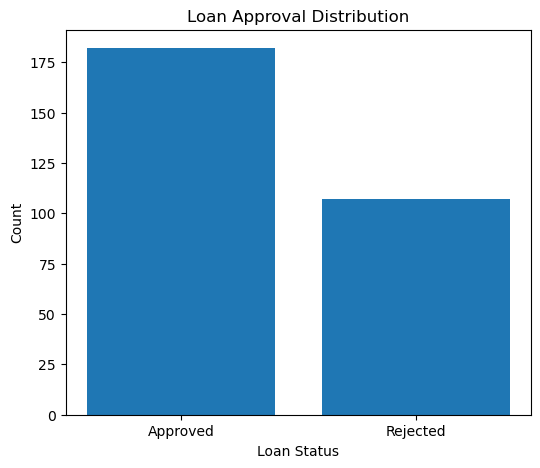

In [27]:
loan_counts = df['Loan_Status'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ['Approved', 'Rejected'],
    loan_counts.values
)

plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Loan Approval Distribution')

plt.show()

# 📌 Step 7 — Check Data Types

In [28]:
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status            int64
dtype: object


# 📌 Step 9 — Remove Loan_ID Column

In [29]:
df = df.drop('Loan_ID', axis=1)

print(df.head())

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male     Yes          0      Graduate            No             5720   
1   Male     Yes          1      Graduate            No             3076   
2   Male     Yes          2      Graduate            No             5000   
3   Male      No          0  Not Graduate            No             3276   
4   Male     Yes          0  Not Graduate           Yes             2165   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3                  0        78.0             360.0             1.0   
4               3422       152.0             360.0             1.0   

  Property_Area  Loan_Status  
0         Urban            1  
1         Urban            1  
2         Urban            1 

# 📌 Step 9 — Encode Categorical Columns

In [30]:
le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           0          0              0             5720   
1       1        1           1          0              0             3076   
2       1        1           2          0              0             5000   
3       1        0           0          1              0             3276   
4       1        1           0          1              1             2165   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3                  0        78.0             360.0             1.0   
4               3422       152.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              2            1  
2              2    

# 📌 Step 10 — Features and Target

In [31]:
# Independent Variables
X = df.drop('Loan_Status', axis=1)

# Dependent Variable
y = df['Loan_Status']

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (289, 11)
y Shape : (289,)


# 📌 Step 11 — Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (231, 11)
Testing Data Shape : (58, 11)


# 📌 Step 12 — Build Decision Tree Model

In [33]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


# 📌 Step 13 — Prediction

In [34]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0
 1 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 0]


# 📌 Step 14 — Accuracy Score

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.9827586206896551


# 📌 Step 15 — Confusion Matrix

In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[24  0]
 [ 1 33]]


# 📌 Step 16 — Confusion Matrix Graph

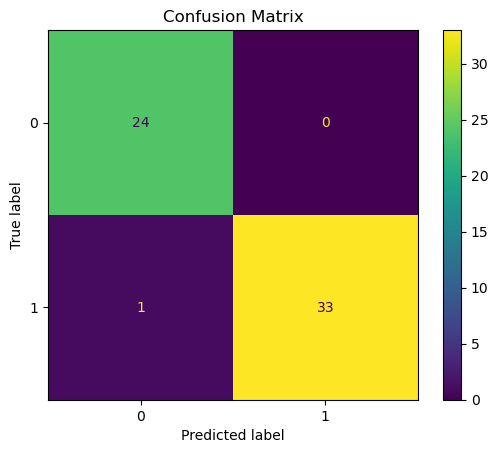

In [37]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")

plt.show()

# 📌 Step 17 — Classification Report

In [38]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.97      0.99        34

    accuracy                           0.98        58
   macro avg       0.98      0.99      0.98        58
weighted avg       0.98      0.98      0.98        58



# 📌 Step 18 — Feature Importance

In [39]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
5     ApplicantIncome    0.698215
9      Credit_History    0.301785
0              Gender    0.000000
1             Married    0.000000
2          Dependents    0.000000
3           Education    0.000000
4       Self_Employed    0.000000
6   CoapplicantIncome    0.000000
7          LoanAmount    0.000000
8    Loan_Amount_Term    0.000000
10      Property_Area    0.000000


# 📌 Step 19 — Feature Importance Graph

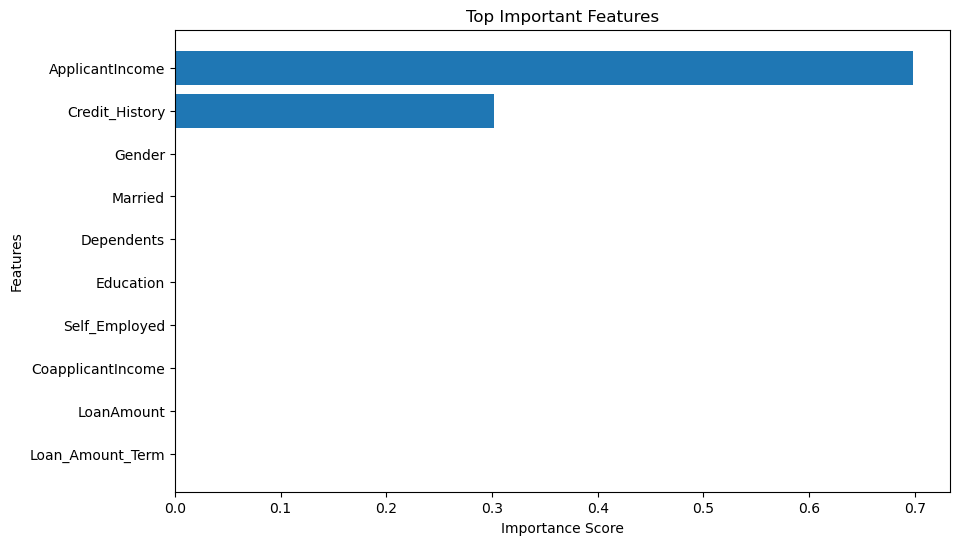

In [40]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top Important Features')

plt.gca().invert_yaxis()

plt.show()

# 📌 Step 20 — Decision Tree Visualization

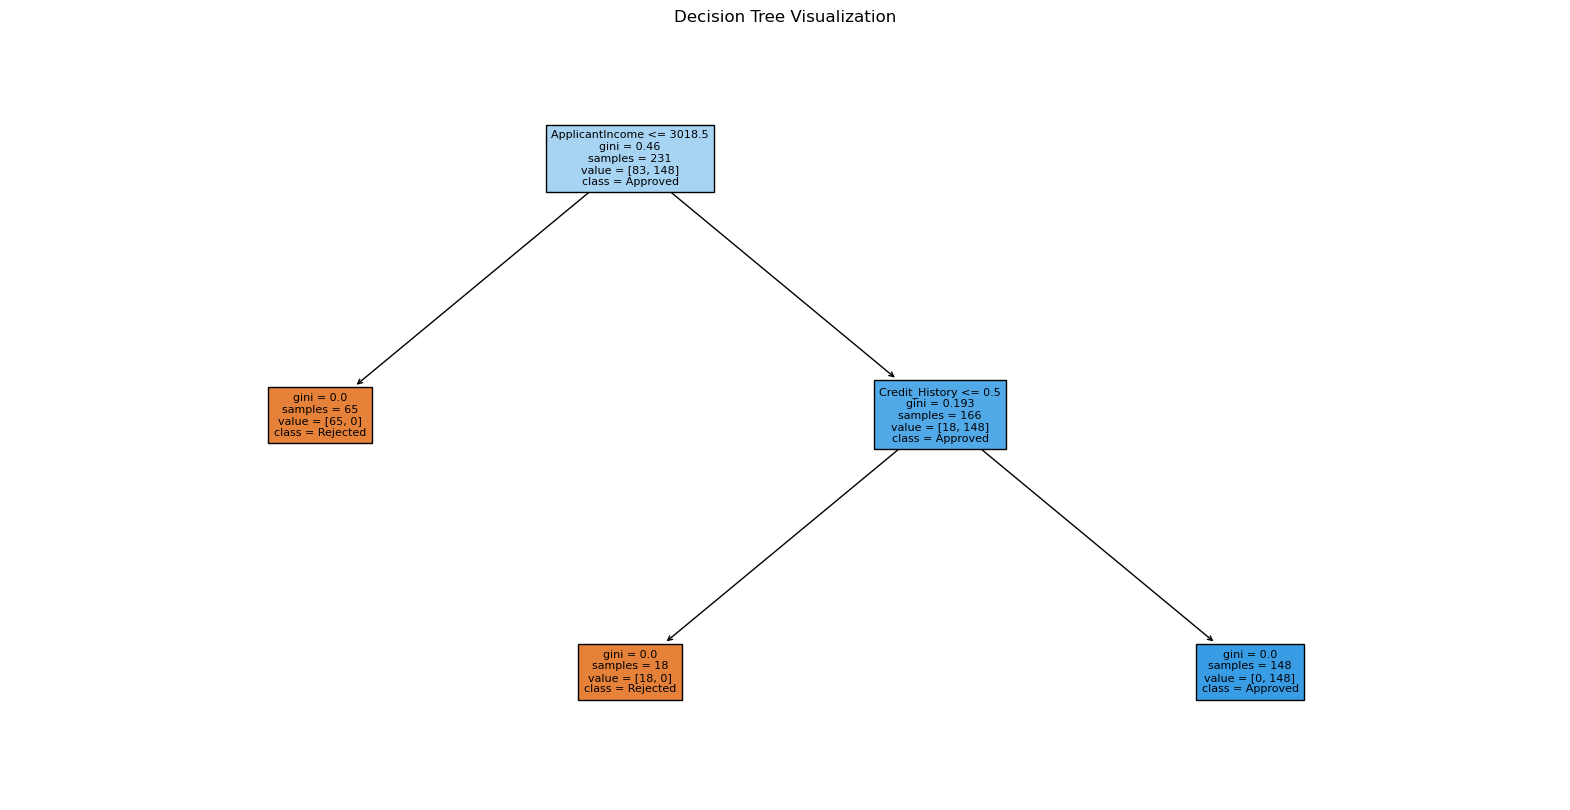

In [41]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

# 📌 Step 21 — Compare Actual vs Predicted

In [42]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        1          1
3        0          0
4        0          0
5        1          1
6        1          1
7        0          0
8        1          1
9        1          1
10       0          0
11       0          0
12       1          1
13       0          0
14       0          0
15       1          1
16       0          0
17       1          1
18       1          1
19       1          1


# 📌 Step 22 — Predict Single New Customer

In [43]:
sample_data = X_test.iloc[0:1]

prediction = model.predict(sample_data)

print("Prediction :", prediction)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Prediction : [0]
Loan Rejected


# 📌 Step 23 — Overfitting Check

In [44]:
# Training Prediction
train_pred = model.predict(X_train)

# Training Accuracy
train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy  : 0.9827586206896551


# 📌 Step 24 — Decision Tree Using Entropy

In [46]:
entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Entropy Model Accuracy :", entropy_accuracy)

Entropy Model Accuracy : 0.9827586206896551


# 📌 Step 25 — Compare Gini vs Entropy

In [47]:
comparison_df = pd.DataFrame({
    'Model': ['Gini', 'Entropy'],
    'Accuracy': [test_accuracy, entropy_accuracy]
})

print(comparison_df)

     Model  Accuracy
0     Gini  0.982759
1  Entropy  0.982759


# 📌 Step 26 — Accuracy Comparison Graph

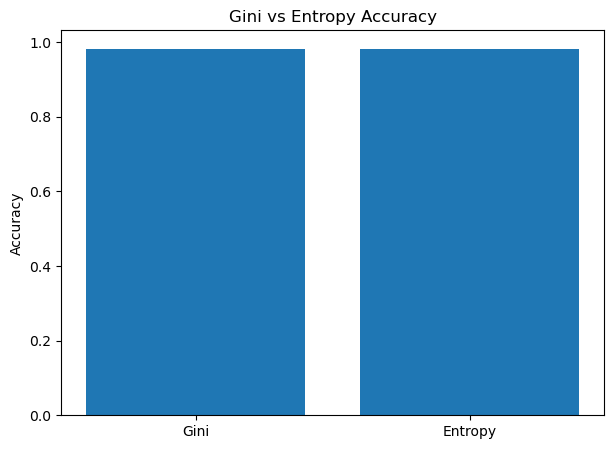

In [48]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.ylabel('Accuracy')
plt.title('Gini vs Entropy Accuracy')

plt.show()